## CPU Anomlay Detector

let’s build a CPU anomaly detector using an Autoencoder.

The idea:

   - Train the autoencoder only on normal CPU usage patterns.

   - When new data is fed, if reconstruction error is high → it’s likely an anomaly.

### Concept Recap

- The encoder compresses CPU usage patterns into a smaller representation.

- The decoder tries to reconstruct them.

- During training, it learns the “normal” behavior.

- During testing, if CPU usage behaves unusually, the reconstruction error (MSE) will spike.

In [1]:
!pip install -q tensorflow matplotlib numpy

Model: "CPU_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 405 (1.58 KB)

 Trainable params: 405 (1.58 KB)

 Non-trainable params: 0 (0.00 B)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
High anomaly threshold: 0.07151
Low anomaly threshold:  -0.33459
Detected 30 abnormal CPU usage points.


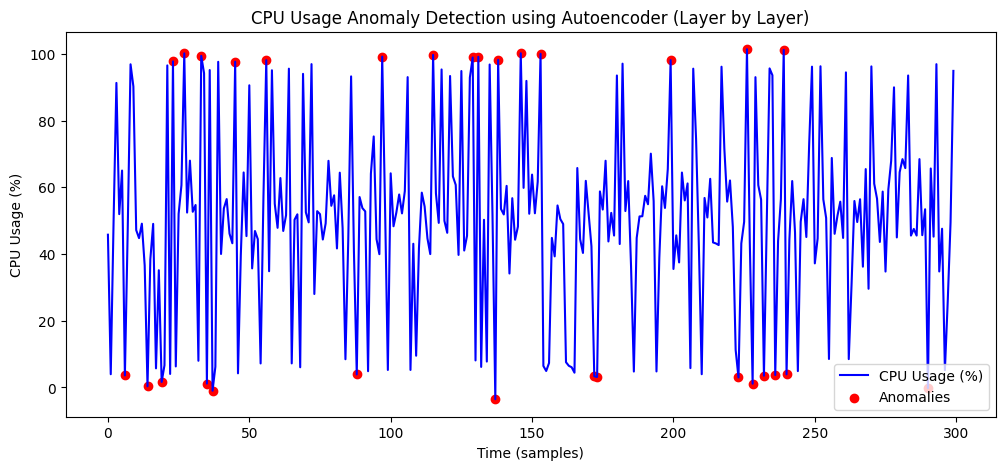

⚠️ Alert: Abnormal CPU usage detected at index 6 → 3.60%
⚠️ Alert: Abnormal CPU usage detected at index 14 → 0.33%
⚠️ Alert: Abnormal CPU usage detected at index 19 → 1.64%
⚠️ Alert: Abnormal CPU usage detected at index 23 → 97.77%
⚠️ Alert: Abnormal CPU usage detected at index 27 → 100.18%
⚠️ Alert: Abnormal CPU usage detected at index 33 → 99.43%
⚠️ Alert: Abnormal CPU usage detected at index 35 → 1.15%
⚠️ Alert: Abnormal CPU usage detected at index 37 → -0.99%
⚠️ Alert: Abnormal CPU usage detected at index 45 → 97.69%
⚠️ Alert: Abnormal CPU usage detected at index 56 → 98.14%
⚠️ Alert: Abnormal CPU usage detected at index 88 → 3.89%
⚠️ Alert: Abnormal CPU usage detected at index 97 → 99.20%
⚠️ Alert: Abnormal CPU usage detected at index 115 → 99.72%
⚠️ Alert: Abnormal CPU usage detected at index 129 → 98.95%
⚠️ Alert: Abnormal CPU usage detected at index 131 → 99.14%
⚠️ Alert: Abnormal CPU usage detected at index 137 → -3.55%
⚠️ Alert: Abnormal CPU usage detected at index 138 → 98.2

In [10]:
# ================================================
# 🧠 CPU Usage Anomaly Detection (Layer by Layer)
# ================================================

# ---------------------------------------------------
# 1️⃣ Import dependencies
# ---------------------------------------------------
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# ---------------------------------------------------
# 2️⃣ Simulate Server CPU Usage Data
# ---------------------------------------------------
np.random.seed(42)

# Normal CPU usage
normal_cpu = np.random.normal(loc=50, scale=10, size=(1000, 1))
normal_cpu = np.clip(normal_cpu, 0, 100)

# High spikes and low drops
spikes = np.random.normal(loc=95, scale=3, size=(50, 1))
drops  = np.random.normal(loc=5,  scale=3, size=(50, 1))
abnormal_cpu = np.concatenate([spikes, drops])

# Split into train/test
x_train = normal_cpu[:800]                       # Only normal for training
x_test  = np.concatenate([normal_cpu[800:], abnormal_cpu])

# Shuffle the combined test set
# np.random.shuffle(x_test)

# ---------------------------------------------------
# 3️⃣ Normalize Data
# ---------------------------------------------------
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

# ---------------------------------------------------
# 4️⃣ Build Autoencoder
# ---------------------------------------------------
input_layer = keras.Input(shape=(1,), name="input_layer")

# Encoder
encoded_1 = layers.Dense(16, activation="relu")(input_layer)
encoded_2 = layers.Dense(8, activation="relu")(encoded_1)

# Bottleneck
bottleneck = layers.Dense(4, activation="relu")(encoded_2)

# Decoder
decoded_1 = layers.Dense(8, activation="relu")(bottleneck)
decoded_2 = layers.Dense(16, activation="relu")(decoded_1)

# Output
output_layer = layers.Dense(1, activation="linear")(decoded_2)

autoencoder = keras.Model(inputs=input_layer, outputs=output_layer, name="CPU_Autoencoder")
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

# ---------------------------------------------------
# 5️⃣ Train Autoencoder
# ---------------------------------------------------
history = autoencoder.fit(
    x_train_scaled, x_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# ---------------------------------------------------
# 6️⃣ Reconstruct and Calculate Error
# ---------------------------------------------------
reconstructions = autoencoder.predict(x_test_scaled)
reconstruction_error = np.abs(x_test_scaled - reconstructions).flatten()  # Absolute error for better detection

# ---------------------------------------------------
# 7️⃣ Define separate thresholds for high and low anomalies
# ---------------------------------------------------
reconstruction_error = (x_test_scaled - reconstructions).flatten()  # Keep signed error

# High anomaly = reconstructed value << actual value → error positive
threshold_high = np.percentile(reconstruction_error, 95)
# Low anomaly = reconstructed value >> actual value → error negative
threshold_low  = np.percentile(reconstruction_error, 5)

print(f"High anomaly threshold: {threshold_high:.5f}")
print(f"Low anomaly threshold:  {threshold_low:.5f}")

# ---------------------------------------------------
# 8️⃣ Identify Anomalies
# ---------------------------------------------------
anomaly_flags_high = reconstruction_error > threshold_high
anomaly_flags_low  = reconstruction_error < threshold_low
anomaly_flags = anomaly_flags_high | anomaly_flags_low
detected_anomalies = np.where(anomaly_flags)[0]

print(f"Detected {len(detected_anomalies)} abnormal CPU usage points.")


# ---------------------------------------------------
# 9️⃣ Visualize Results
# ---------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(x_test, label="CPU Usage (%)", color="blue")
plt.scatter(detected_anomalies, x_test[detected_anomalies], color="red", label="Anomalies")
plt.title("CPU Usage Anomaly Detection using Autoencoder (Layer by Layer)")
plt.xlabel("Time (samples)")
plt.ylabel("CPU Usage (%)")
plt.legend()
plt.show()

# ---------------------------------------------------
# 🔟 Optional: Trigger Alerts
# ---------------------------------------------------
for idx in detected_anomalies:
    print(f"⚠️ Alert: Abnormal CPU usage detected at index {idx} → {x_test[idx][0]:.2f}%")
